In [22]:
# -----------------------------
# 1. Import libraries
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


In [12]:
# -----------------------------
# 2. Create dataset
# -----------------------------
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)


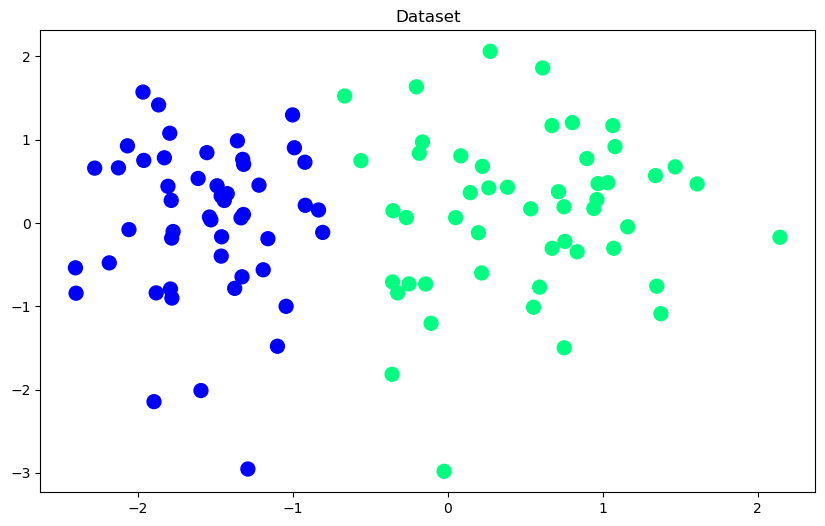

In [13]:
# -----------------------------
# 3. Plot dataset
# -----------------------------
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.title("Dataset")
plt.show()


In [14]:
def step(z):
    if z > 0:
        return 1
    else:
        return 0


In [18]:
class SimplePerceptron:

    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None


    def fit(self, X, y):
        # add bias column (X0 = 1)
        X = np.insert(X, 0, 1, axis=1)

        # initialize weights
        self.weights = np.ones(X.shape[1])

        for i in range(self.epochs):
            j = np.random.randint(0, X.shape[0])

            z = np.dot(X[j], self.weights)
            y_hat = step(z)

            # update rule
            self.weights = self.weights + self.lr * (y[j] - y_hat) * X[j]

    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)

        y_pred = []
        for i in range(X.shape[0]):
            z = np.dot(X[i], self.weights)
            y_pred.append(step(z))

        return np.array(y_pred)
        
    def get_line(self):
        w0 = self.weights[0]
        w1 = self.weights[1]
        w2 = self.weights[2]

        m = -(w1 / w2)
        b = -(w0 / w2)

        return m, b


In [37]:
model = SimplePerceptron(lr=0.01, epochs=200)
model.fit(X, y)

In [38]:
y_pred = model.predict(X)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [1 1 0 0 1 1 0 1 1 0]


In [39]:
# accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)*100



89.0

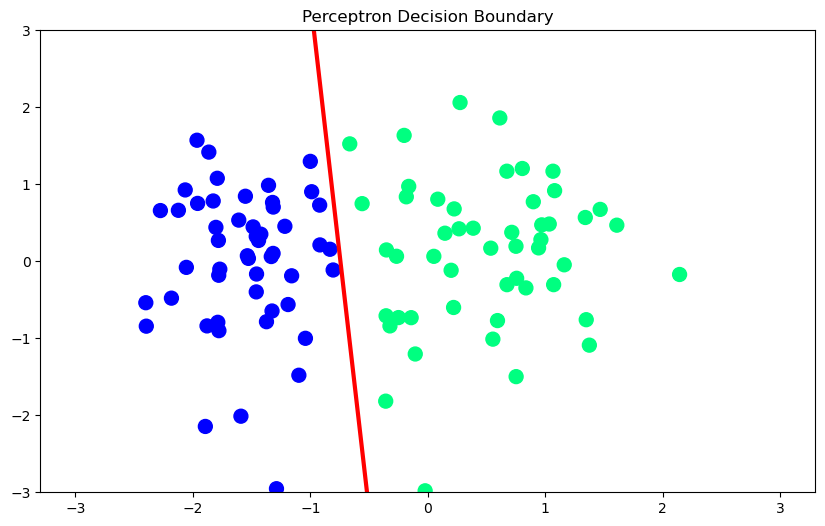

In [21]:
m, b = model.get_line()

x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3, 3)
plt.title("Perceptron Decision Boundary")
plt.show()
